# 07 — Regional Analysis
**Phase 7 — Brazilian E-Commerce Analytics (Olist)**

Business questions answered:
- Which states generate the most revenue and orders?
- Which states have the highest average order value?
- Which states have the slowest and fastest delivery times?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import get_engine

engine = get_engine()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
query = """
    SELECT
        c.customer_state                         AS state,
        COUNT(DISTINCT o.order_id)               AS total_orders,
        ROUND(SUM(op.payment_value)::numeric, 2) AS revenue
    FROM customers_clean c
    JOIN orders_clean o    ON c.customer_id = o.customer_id
    JOIN order_payments op ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY state
    ORDER BY revenue DESC
"""

state_revenue = pd.read_sql(query, engine)
state_revenue

,state,total_orders,revenue
0,SP,40500,5770266.19
1,RJ,12350,2055690.45
2,MG,11354,1819277.61
3,RS,5345,861802.40
4,PR,4923,781919.55
5,SC,3546,595208.40
6,BA,3256,591270.60
7,DF,2080,346146.17
8,GO,1957,334294.22
9,ES,1995,317682.65


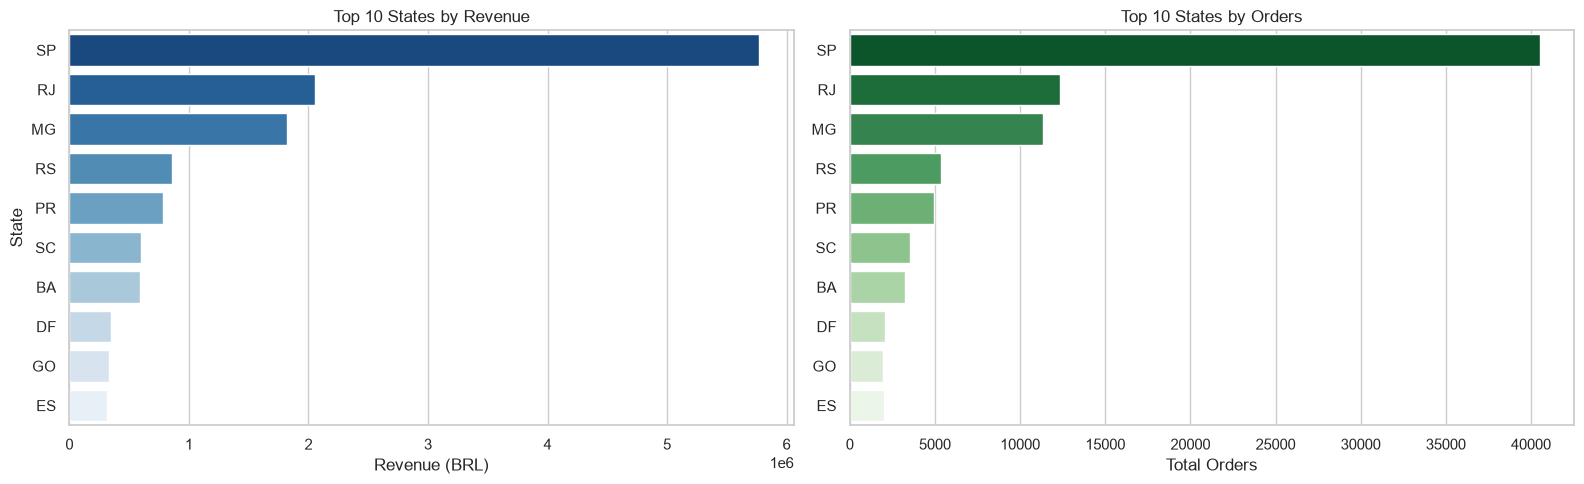

In [3]:
top10 = state_revenue.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=top10, x="revenue", y="state",
    hue="state", palette="Blues_r", legend=False, ax=axes[0]
)
axes[0].set_title("Top 10 States by Revenue")
axes[0].set_xlabel("Revenue (BRL)")
axes[0].set_ylabel("State")

sns.barplot(
    data=top10, x="total_orders", y="state",
    hue="state", palette="Greens_r", legend=False, ax=axes[1]
)
axes[1].set_title("Top 10 States by Orders")
axes[1].set_xlabel("Total Orders")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

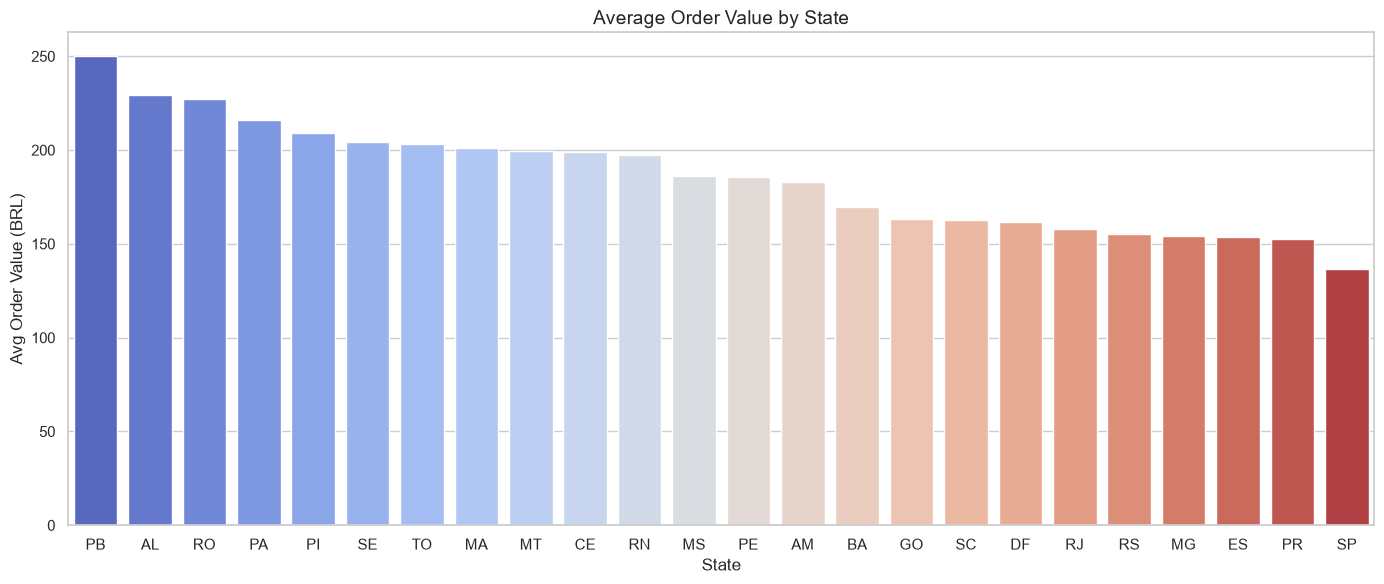

In [4]:
query = """
    SELECT
        c.customer_state                         AS state,
        ROUND(AVG(op.payment_value)::numeric, 2) AS avg_order_value,
        COUNT(DISTINCT o.order_id)               AS total_orders
    FROM customers_clean c
    JOIN orders_clean o    ON c.customer_id = o.customer_id
    JOIN order_payments op ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY state
    HAVING COUNT(DISTINCT o.order_id) > 100
    ORDER BY avg_order_value DESC
"""

avg_state = pd.read_sql(query, engine)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=avg_state, x="state", y="avg_order_value",
    hue="state", palette="coolwarm", legend=False
)
plt.title("Average Order Value by State", fontsize=14)
plt.xlabel("State")
plt.ylabel("Avg Order Value (BRL)")
plt.tight_layout()
plt.show()

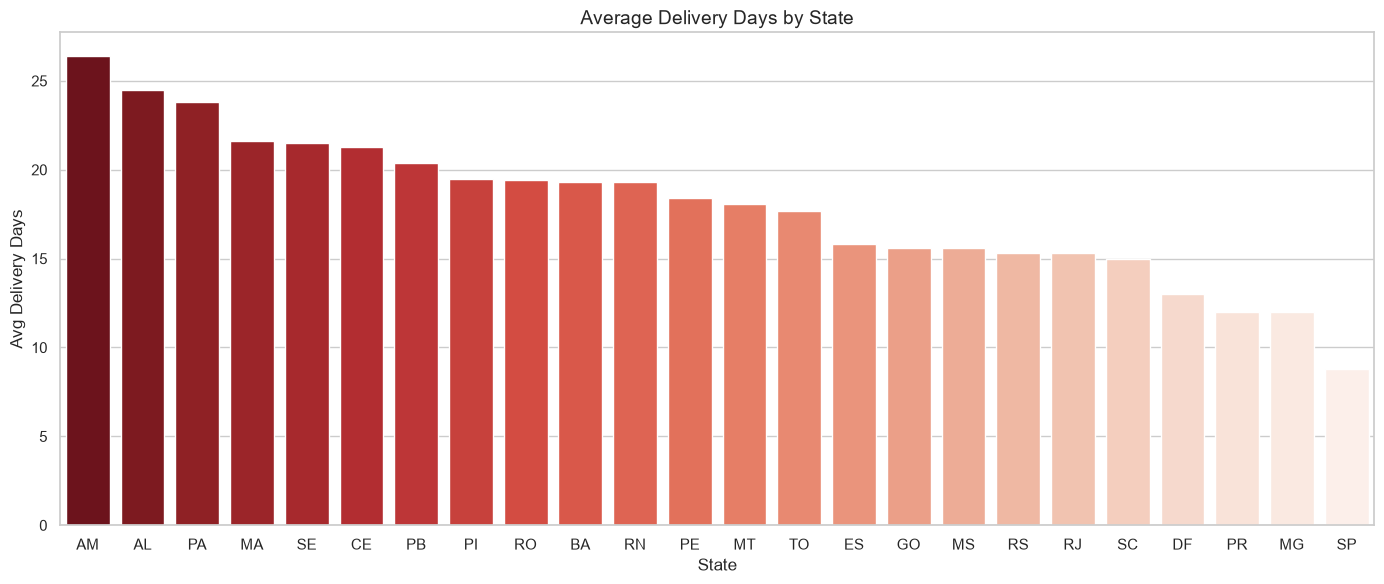

In [5]:
query = """
    SELECT
        c.customer_state AS state,
        ROUND(AVG(
            EXTRACT(EPOCH FROM (
                o.order_delivered_customer_date - o.order_purchase_timestamp
            )) / 86400
        )::numeric, 1) AS avg_delivery_days
    FROM customers_clean c
    JOIN orders_clean o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY state
    HAVING COUNT(*) > 100
    ORDER BY avg_delivery_days DESC
"""

delivery = pd.read_sql(query, engine)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=delivery, x="state", y="avg_delivery_days",
    hue="state", palette="Reds_r", legend=False
)
plt.title("Average Delivery Days by State", fontsize=14)
plt.xlabel("State")
plt.ylabel("Avg Delivery Days")
plt.tight_layout()
plt.show()

In [6]:
print("📊 Regional Analysis Summary\n")
print(f"🏆 Highest Revenue State:     {state_revenue.iloc[0]['state']} — BRL {state_revenue.iloc[0]['revenue']:,}")
print(f"📦 Most Orders State:         {state_revenue.sort_values('total_orders', ascending=False).iloc[0]['state']}")
print(f"💰 Highest Avg Order Value:   {avg_state.iloc[0]['state']} — BRL {avg_state.iloc[0]['avg_order_value']}")
print(f"🚚 Slowest Delivery State:    {delivery.iloc[0]['state']} — {delivery.iloc[0]['avg_delivery_days']} days")
print(f"⚡ Fastest Delivery State:    {delivery.iloc[-1]['state']} — {delivery.iloc[-1]['avg_delivery_days']} days")

📊 Regional Analysis Summary

🏆 Highest Revenue State:     SP — BRL 5,770,266.19
📦 Most Orders State:         SP
💰 Highest Avg Order Value:   PB — BRL 250.15
🚚 Slowest Delivery State:    AM — 26.4 days
⚡ Fastest Delivery State:    SP — 8.8 days
